# DQN

In this notebook, we will implement Deep Q-Learning Reinforcement learning algorithm for Lunar Lander Environment.

## Lunar Lander

This environment is a classic rocket trajectory optimization problem. The landing pad is always at coordinates (0,0). The state is an 8-dimensional vector: the coordinates of the lander in x & y, its linear velocities in x & y, its angle, its angular velocity, and two booleans that represent whether each leg is in contact with the ground or not.

There are four discrete actions available:<br>
- 0: do nothing<br>
- 1: fire left orientation engine<br>
- 2: fire main engine<br>
- 3: fire right orientation engine<br>

After every step a reward is granted. The total reward of an episode is the sum of the rewards for all the steps within that episode.

For each step, the reward:

- is increased/decreased the closer/further the lander is to the landing pad.

- is increased/decreased the slower/faster the lander is moving.

- is decreased the more the lander is tilted (angle not horizontal).

- is increased by 10 points for each leg that is in contact with the ground.

- is decreased by 0.03 points each frame a side engine is firing.

- is decreased by 0.3 points each frame the main engine is firing.

The episode receive an additional reward of -100 or +100 points for crashing or landing safely respectively.

An episode is considered a solution if it scores at least 200 points.


You can read more the LunarLander environment [here](https://gymnasium.farama.org/environments/box2d/lunar_lander/)

![LunarLander](https://gymnasium.farama.org/_images/lunar_lander.gif)

## Deep Q-Learning

The main idea behind Q-learning is that if we had a function $Q^*:\text{State}\times\text{Action}\to\mathbb{R}$ that could tell us what our return would be if we were to take an action in a given state, then we could easily construct a policy that maximizes our rewards:
$$
\pi^*(s)=\arg\max_a\,Q^*(s,a). \tag{1}
$$
But this is not scalable. We would need to compute $Q(s,a)$ for every state–action pair. If the state is, e.g., raw pixels of a game screen, it is computationally infeasible to cover the entire state space. Since neural networks are universal function approximators, we can create one and train it to resemble $Q^*$.

For our training update rule, every $Q$ function for a policy $\pi$ obeys the (policy) Bellman equation (expectations made explicit):
$$
Q^{\pi}(s,a)=\mathbb{E}_{\,s'\sim P(\cdot\mid s,a)}\!\Big[r(s,a)+\gamma\,\mathbb{E}_{\,a'\sim\pi(\cdot\mid s')}\big[Q^{\pi}(s',a')\big]\Big]. \tag{2}
$$

In DQN (off-policy), we use the optimal Bellman target (with a max over actions). The temporal-difference error $\delta$ is:
$$
\delta \;=\; Q(s,a;\theta)\;-\;\Big(r(s,a)\;+\;\gamma\,\max_{a'} Q_{\text{target}}(s',a')\Big). \tag{3}
$$

To minimise this error, we use the [Huber loss](https://en.wikipedia.org/wiki/Huber_loss), computed over a minibatch $B$ sampled from replay memory:
$$
\mathcal{L}(\theta)=\frac{1}{|B|}\sum_{(s,a,r,s')\in B}\,\mathcal{L}_{\text{Huber}}\!\big(\delta\big). \tag{4}
$$

$$
\mathcal{L}_{\text{Huber}}(\delta)=
\begin{cases}
\dfrac{1}{2}\,\delta^2, & \text{if } |\delta|\le 1,\\[4pt]
|\delta|-\dfrac{1}{2}, & \text{otherwise.}
\end{cases} \tag{5}
$$


In [14]:
!pip install swig
!pip install "gymnasium[box2d]"


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [15]:
import gymnasium as gym
import math
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple
from itertools import count
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T

In [16]:
# if gpu is to be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [17]:
# Create the environment
env = gym.make("LunarLander-v3")

## T3: Experience Replay

In [18]:
# --- T3: Replay Memory ---
class ReplayMemory(object):
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, state, action, reward, next_state, done):
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = (state, action, reward, next_state, done)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)


Learning from batches of consecutive samples is problematic as the sample are correlated and it can create a bad feedback loop if one action is dominated in the samples.

We can address these problems using an experience replay memory. It maintains a record for all the transitions experienced. The agent is then trained by sampling random minibatches from the replay memory.

## T1: Q-Network

In [19]:
# --- T1: Network architecture and components ---
class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

n_observations = env.observation_space.shape[0]
n_actions = env.action_space.n

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()


DQN(
  (layer1): Linear(in_features=8, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=128, bias=True)
  (layer3): Linear(in_features=128, out_features=4, bias=True)
)

## T3: Exploration vs Exploitation

In [20]:
# --- T3: Epsilon-Greedy Policy ---
def get_action(state, epsilon=0.0):
    if random.random() > epsilon:
        with torch.no_grad():
            return policy_net(state).max(1)[1].view(1, 1)
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)


Notice that Q-learning only learns about the states and actions it visits. What if an optimal state remains unvisited due to not being explored. The agent should sometimes pick suboptimal actions in order to visit new states and actions. <br>

A simple strategy is to use an $\epsilon$-greedy policy. According to this policy, the agent takes a random action with epsilon probability. The value of epsilon is high at the start of training and low towards the end. So, the agent explores more at the start and then exploit the learned policy more at the end.

## T1 & T3: Hyperparameters

In [21]:
# --- T1 & T3: Hyperparameters ---
BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 1.0
EPS_END = 0.01
EPS_DECAY = 15000 # Epsilon decay by steps
TAU = 0.005 
LR = 5e-4

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)

steps_done = 0
def get_epsilon(steps):
    return EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps / EPS_DECAY)


## T3: Training

In [22]:
# --- T3: Training loop and update procedure ---
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    batch = list(zip(*transitions))

    state_batch = torch.cat(batch[0])
    action_batch = torch.cat(batch[1])
    reward_batch = torch.cat(batch[2])
    
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not True, batch[4])), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s, done in zip(batch[3], batch[4]) if not done])

    state_action_values = policy_net(state_batch).gather(1, action_batch)

    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0]
    
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

num_episodes = 600
rewards = []
max_steps = 1000

for i_episode in range(num_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    
    total_reward = 0
    
    for t in range(max_steps):
        epsilon = get_epsilon(steps_done)
        action = get_action(state, epsilon)
        steps_done += 1
        
        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward_tensor = torch.tensor([reward], device=device)
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        memory.push(state, action, reward_tensor, next_state, done)
        state = next_state
        total_reward += reward

        optimize_model()

        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            break
            
    rewards.append(total_reward)
    if i_episode % 50 == 0:
        print(f"Episode {i_episode}, Total Reward: {total_reward:.2f}, Epsilon: {epsilon:.3f}")

print("Training Complete")


Episode 0, Total Reward: -121.72, Epsilon: 0.995
Episode 50, Total Reward: -142.37, Epsilon: 0.724
Episode 100, Total Reward: -134.40, Epsilon: 0.493
Episode 150, Total Reward: 210.69, Epsilon: 0.082
Episode 200, Total Reward: 134.69, Epsilon: 0.014
Episode 250, Total Reward: 204.76, Epsilon: 0.010
Episode 300, Total Reward: 191.46, Epsilon: 0.010
Episode 350, Total Reward: 227.19, Epsilon: 0.010
Episode 400, Total Reward: 278.15, Epsilon: 0.010
Episode 450, Total Reward: 272.82, Epsilon: 0.010
Episode 500, Total Reward: 235.34, Epsilon: 0.010
Episode 550, Total Reward: 236.98, Epsilon: 0.010
Training Complete


## T4: Visualization

In [23]:
# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob
import base64, io, os


os.environ['SDL_VIDEODRIVER'] = 'dummy'

In [24]:
# --- T4: Environment Visualization ---


# Video folder
os.makedirs("video", exist_ok=True)

def show_video(env_name):
    """Display the saved MP4 inline."""
    mp4 = f'video/{env_name}.mp4'
    if os.path.exists(mp4):
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display.display(HTML(data=f'''
            <video alt="evaluation" autoplay loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{encoded.decode('ascii')}" type="video/mp4" />
            </video>'''))
    else:
        print("Could not find video")

def show_video_of_model(env_name, greedy=True, seed=None):
    """
    Record one evaluation episode into video/<env_name>.mp4.
    - greedy=True: use the greedy action (no epsilon exploration) for smooth video.
      Set greedy=False to reuse your epsilon-greedy get_action().
    """
    # Create a fresh environment configured for frame capturing
    env_video = gym.make(env_name, render_mode="rgb_array")
    if seed is not None:
        # Optional: fix the seed for reproducibility
        obs, info = env_video.reset(seed=seed)
    else:
        obs, info = env_video.reset()

    # Prepare recorder
    vid = video_recorder.VideoRecorder(env_video, path=f"video/{env_name}.mp4")

    # Convert observation to float32 tensor with batch dimension
    state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

    for t in range(max_steps):
        # Capture current frame
        vid.capture_frame()

        # Choose action: greedy (no exploration) or your epsilon-greedy policy
        if greedy:
            with torch.no_grad():
                action = policy_net(state).max(1)[1].view(1, 1)  # tensor [[a]]
        else:
            action = get_action(state)  # uses global epsilon

        # Step the environment (Gymnasium API)
        obs, reward, terminated, truncated, info = env_video.step(action.item())
        done_bool = terminated or truncated

        # Next state tensor
        next_state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

        # Advance
        state = next_state

        if done_bool:
            break

    # Finalize
    vid.close()
    env_video.close()

# Record and display
show_video_of_model("LunarLander-v3", greedy=True, seed=42)
show_video("LunarLander-v3")


MoviePy - Building video video/LunarLander-v3.mp4.
MoviePy - Writing video video/LunarLander-v3.mp4



MoviePy - Done !
MoviePy - video ready video/LunarLander-v3.mp4


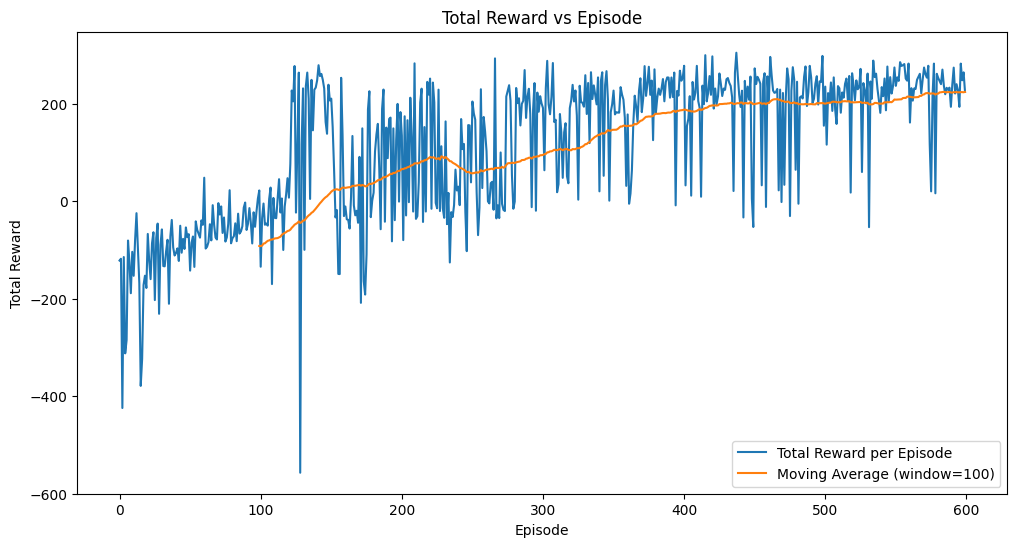

In [25]:
# --- T4: Plotting Learning Curve ---
import matplotlib.pyplot as plt

def plot_rewards(rewards, window=100):
    plt.figure(figsize=(12, 6))
    plt.plot(rewards, label='Total Reward per Episode')

    if len(rewards) >= window:
        moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(range(window-1, len(rewards)), moving_avg, label=f'Moving Average (window={window})')

    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('Total Reward vs Episode')
    plt.legend()
    plt.show()

plot_rewards(rewards)


In [26]:
# --- T4: Evaluation ---
# Report (Gymnasium-compatible, greedy evaluation)
evaluation_episodes = 100
evaluation_rewards = []

for episode in range(evaluation_episodes):
    # Gymnasium reset -> (obs, info)
    obs, info = env.reset()
    # to float32 tensor + batch dim
    state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

    total_rewards = 0.0

    for _ in range(max_steps):
        # Greedy action from the policy network (no epsilon)
        with torch.no_grad():
            action = policy_net(state).max(1)[1].view(1, 1)  # tensor [[a]]

        # Gymnasium step -> (obs, reward, terminated, truncated, info)
        obs, reward, terminated, truncated, info = env.step(action.item())
        done = terminated or truncated

        total_rewards += reward

        # next state tensor
        state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

        if done:
            break

    evaluation_rewards.append(total_rewards)

mean_reward = float(np.mean(evaluation_rewards))
std_reward = float(np.std(evaluation_rewards))
print(f"Mean reward over {evaluation_episodes} episodes: {mean_reward:.2f}")
print(f"Std of rewards over {evaluation_episodes} episodes: {std_reward:.2f}")


Mean reward over 100 episodes: 166.96
Std of rewards over 100 episodes: 108.24


# Detailed Explanations for Tasks

## T1. Network architecture and components
* **Input dimension:** The input dimension is 8, matching the state space of LunarLander-v3.
* **Output dimension:** The output dimension is 4, matching the discrete action space of the environment.
* **Architecture:** The network consists of an input layer, two hidden layers of 128 neurons each, and an output layer. We use `ReLU` activation functions after each hidden layer. The output layer has no activation, as it outputs the raw Q-values for each action.
* **Target Network:** The target network is created as a clone of the policy network, `target_net.load_state_dict(policy_net.state_dict())`. It is updated smoothly every step using soft updates controlled by the hyperparameter `TAU`.

## T2. Explanation of DQN components
* **Replay buffer:** It stores previous experiences (state, action, reward, next_state, done) and samples random minibatches for training. This breaks temporal correlations in the data.
* **Target network:** We use a separate network to compute the TD target. It slowly tracks the policy network, which helps stabilize training.
* **Epsilon-greedy policy:** It manages the exploration-exploitation trade-off. We decay epsilon based on `steps_done` so the agent explores initially and exploits later.

## T3. Core code explanation and understanding
* **Creation and purpose of Replay Memory:** 
  The `ReplayMemory` class implements a cyclic buffer. It's needed for experience replay, improving sample efficiency and stabilizing the learning process.
* **Two networks (policy and target):** 
  `policy_net` is optimized actively, while `target_net` provides stable Q-value estimates for computing the TD target. 
* **Computation of the DQN target:**
  We compute the target as `reward + GAMMA * max_a(Q_target(next_state, a))`. In the code, this happens in `expected_state_action_values = (next_state_values * GAMMA) + reward_batch`.
* **Training loop and update procedure:**
  In `optimize_model()`, we sample a batch, construct the state/action/reward tensors. We compute `state_action_values` via the policy network, and `next_state_values` via the target network. We use `Huber loss` and perform an optimizer step.
* **Epsilon decay schedule:**
  Epsilon starts at `EPS_START` and exponentially decays to `EPS_END` based on the formula `EPS_END + (EPS_START - EPS_END) * exp(-steps_done / EPS_DECAY)`. This ensures exploration early in training and exploitation as the policy converges.

